# Understanding Machine Learning Classification

**A practical guide for the pancreas ultrasound radiomics project**

This notebook walks through the concepts of machine learning classification from scratch. By the end, you should understand:
- What a classifier does and how it differs from a statistical test
- How logistic regression and random forests work
- Why train/test splits and cross-validation matter
- What overfitting is and why it is dangerous with our data
- How to interpret AUC, sensitivity, specificity, and precision
- Why our radiomics features yield AUC around 0.5 (chance level)

We will use toy examples first, then apply everything to our real data at the end.

In [1]:
# --- Setup: import libraries we will use throughout ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    recall_score, precision_score
)
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Section 1: From Statistical Tests to Classification

In the previous analysis (notebook 14a), we ran statistical tests on each radiomics feature individually. A statistical test like the Mann-Whitney U test asks a narrow question:

> **"Is this ONE feature different between the rejection and no-rejection groups?"**

We tested all 93 features one at a time and found that none of them showed a statistically significant difference after correcting for multiple comparisons.

A **classifier** asks a fundamentally different question:

> **"Given ALL features together, can I predict which group a new sample belongs to?"**

This is an important distinction. Imagine each feature carries a tiny, non-significant hint about which group a sample belongs to. Individually, those hints are too weak to detect. But a classifier can potentially **combine many weak signals into a stronger prediction**. That is the hope behind using machine learning.

### The key conceptual shift

- **Statistical testing**: examines features one by one, asks whether each feature's distribution differs between groups.
- **Classification**: builds a model that looks at all features simultaneously and learns a **decision rule** -- a recipe for predicting the class of a new, unseen sample.

Think of it this way: a statistical test is like checking whether a single symptom is more common in sick people. A classifier is like a doctor who looks at all symptoms together to make a diagnosis.

---
## Section 2: A Toy Example -- Two Features, Two Classes

Before we touch real data, let's build intuition with a simple synthetic example. We will generate two groups of points in 2D space, where the groups are clearly separable. This is an "easy" classification problem on purpose -- it lets us see how classifiers work before dealing with the messiness of real data.

Dataset shape: (120, 2)
Class 0 (no rejection): 80 samples
Class 1 (rejection):    40 samples


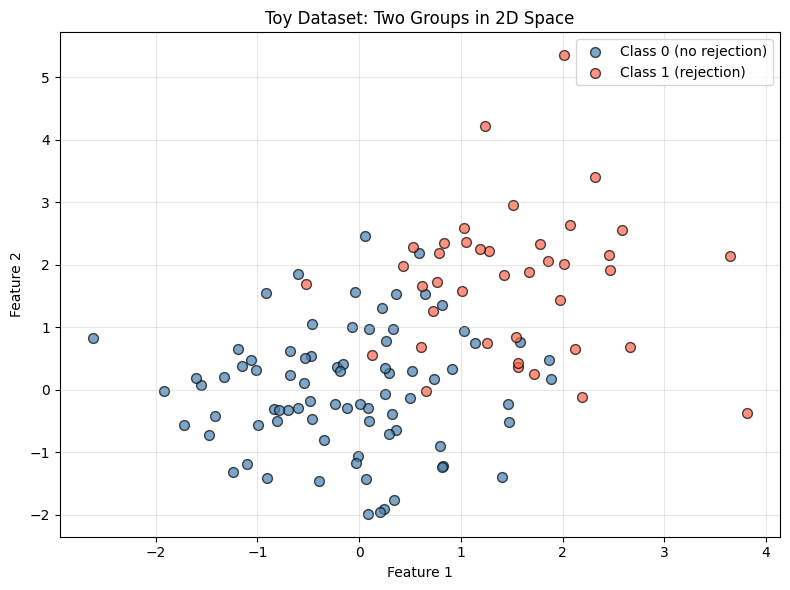

In [2]:
# --- Generate synthetic 2D data with two groups ---
np.random.seed(42)

# Group A ("no rejection"): 80 samples centered at (0, 0)
n_a = 80
group_a = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[1, 0], [0, 1]],  # identity covariance = independent features
    size=n_a
)

# Group B ("rejection"): 40 samples centered at (1.5, 1.5)
n_b = 40
group_b = np.random.multivariate_normal(
    mean=[1.5, 1.5],
    cov=[[1, 0], [0, 1]],
    size=n_b
)

# Combine into a single dataset
X_toy = np.vstack([group_a, group_b])  # shape: (120, 2)
y_toy = np.array([0] * n_a + [1] * n_b)  # 0 = no rejection, 1 = rejection

print(f"Dataset shape: {X_toy.shape}")
print(f"Class 0 (no rejection): {np.sum(y_toy == 0)} samples")
print(f"Class 1 (rejection):    {np.sum(y_toy == 1)} samples")

# Plot the two groups
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_toy[y_toy == 0, 0], X_toy[y_toy == 0, 1],
           c='steelblue', label='Class 0 (no rejection)', alpha=0.7, edgecolors='k', s=50)
ax.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1],
           c='tomato', label='Class 1 (rejection)', alpha=0.7, edgecolors='k', s=50)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Toy Dataset: Two Groups in 2D Space')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Each dot is a sample. Each axis is a feature. The blue dots are centered around (0, 0) and the red dots are centered around (1.5, 1.5). There is some overlap in the middle, but the groups are mostly separable.

**A classifier tries to draw a boundary between the two colors.** Samples on one side of the boundary get predicted as class 0, and samples on the other side get predicted as class 1. The question is: what shape should that boundary be, and where exactly should it go?

---
## Section 3: Logistic Regression

Logistic regression is one of the simplest and most widely used classifiers. Despite its name, it is used for **classification**, not regression.

### How it works

Logistic regression finds a **straight line** (in 2D) or a **flat plane/hyperplane** (in higher dimensions) that best separates the two classes. On one side of the line, samples are predicted as class 0. On the other side, class 1.

Mathematically, for each sample with features $x_1, x_2, \ldots, x_p$, the model computes:

$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + \ldots + w_p \cdot x_p + b$$

where $w_1, w_2, \ldots, w_p$ are the **coefficients** (weights) that the model learns, and $b$ is the **intercept** (bias).

This value $z$ is then fed through the **sigmoid function** (also called the logistic function):

$$P(\text{class 1}) = \frac{1}{1 + e^{-z}}$$

The sigmoid squashes any number into the range (0, 1), which we interpret as the **probability** of belonging to class 1.

- If $P > 0.5$, predict class 1
- If $P \leq 0.5$, predict class 0

### What the coefficients mean

Each coefficient $w_i$ tells you how much feature $i$ matters for the prediction:
- **Positive coefficient**: higher values of this feature push the prediction toward class 1
- **Negative coefficient**: higher values push toward class 0
- **Coefficient near zero**: this feature does not matter much

Logistic Regression Coefficients:
  w1 (Feature 1): 1.714
  w2 (Feature 2): 1.402
  Intercept (b):  -3.086

Both coefficients are positive, meaning higher values of either
feature push the prediction toward class 1 (rejection).
This makes sense because class 1 is centered at (1.5, 1.5).


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


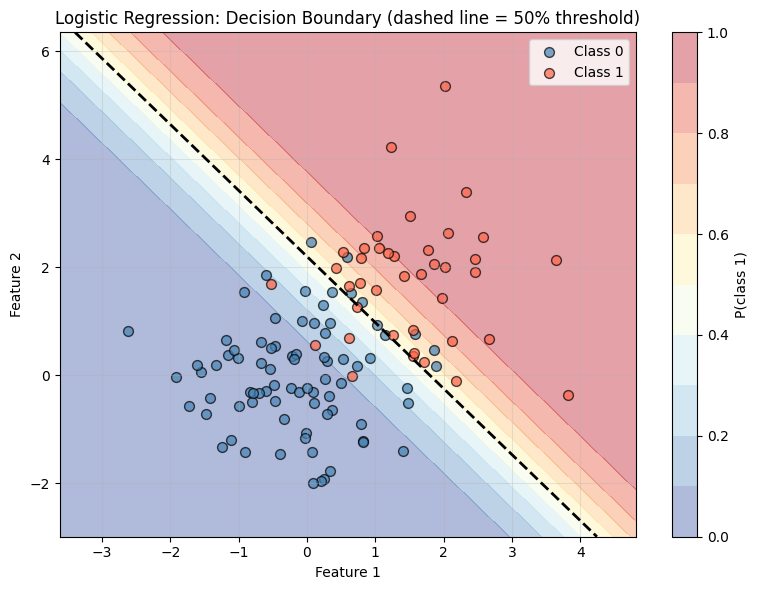

In [3]:
# --- Train logistic regression on the toy data and visualize the decision boundary ---
np.random.seed(42)

# Train the model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_toy, y_toy)

# Print what the model learned
print("Logistic Regression Coefficients:")
print(f"  w1 (Feature 1): {lr_model.coef_[0][0]:.3f}")
print(f"  w2 (Feature 2): {lr_model.coef_[0][1]:.3f}")
print(f"  Intercept (b):  {lr_model.intercept_[0]:.3f}")
print()
print("Both coefficients are positive, meaning higher values of either")
print("feature push the prediction toward class 1 (rejection).")
print("This makes sense because class 1 is centered at (1.5, 1.5).")

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_toy[:, 0].min() - 1, X_toy[:, 0].max() + 1
y_min, y_max = X_toy[:, 1].min() - 1, X_toy[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# Get predicted probabilities for each point on the grid
Z = lr_model.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11),
                       cmap='RdYlBu_r', alpha=0.4)
plt.colorbar(contour, ax=ax, label='P(class 1)')
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.scatter(X_toy[y_toy == 0, 0], X_toy[y_toy == 0, 1],
           c='steelblue', label='Class 0', alpha=0.7, edgecolors='k', s=50)
ax.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1],
           c='tomato', label='Class 1', alpha=0.7, edgecolors='k', s=50)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Logistic Regression: Decision Boundary (dashed line = 50% threshold)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dashed black line is the **decision boundary** -- the line where the model is 50% uncertain. Above/right of the line, the model predicts class 1 (rejection). Below/left, class 0 (no rejection). The color shading shows the predicted probability: deep red means "very likely class 1", deep blue means "very likely class 0".

Notice that the boundary is a **straight line**. Logistic regression can only draw straight boundaries. This is a limitation, but it also means the model is simple and hard to overfit -- which can be an advantage.

---
## Section 4: Random Forest

A random forest is a more complex classifier that can learn non-linear decision boundaries.

### How it works

1. **Build many decision trees** (typically 100 or more). A decision tree is like a flowchart: "Is feature 1 > 0.5? If yes, go left. Is feature 2 > 1.2? If yes, predict class 1."

2. **Each tree sees a different view of the data**: it is trained on a random subset of the samples (with replacement -- some samples appear multiple times, others not at all) and at each split it only considers a random subset of features.

3. **Each tree votes** on the class. The final prediction is the **majority vote** across all trees.

### Why this works

Any single decision tree is a weak learner -- it is noisy and might make mistakes. But by averaging many independent, diverse trees, the random errors cancel out and the true signal remains. It is like asking 100 people to independently estimate the number of jelly beans in a jar: individual guesses vary wildly, but the average is often remarkably accurate.

### Comparison with logistic regression

- Logistic regression: straight boundary, simple, interpretable coefficients
- Random forest: complex, wiggly boundary, can capture non-linear relationships, but harder to interpret

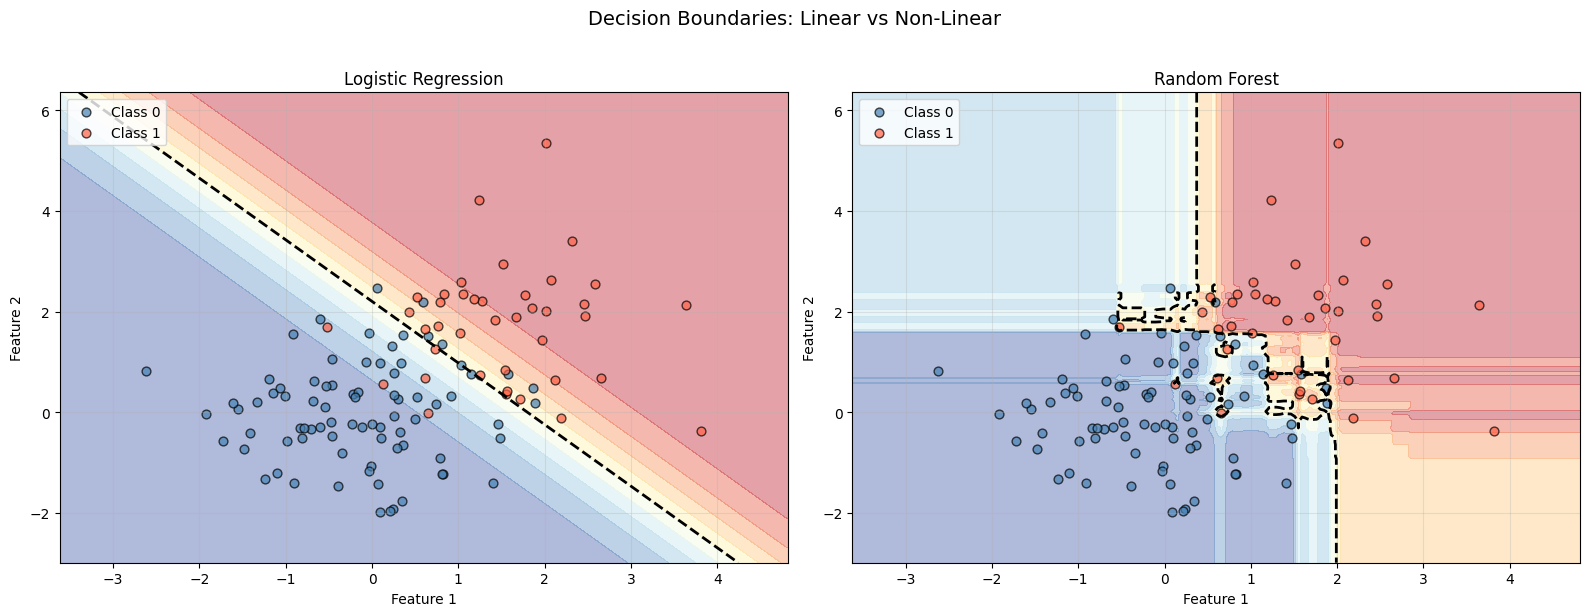

Notice how the random forest boundary is more complex and wiggly.
It can carve out irregular regions, while logistic regression is limited
to a straight line.


In [4]:
# --- Train random forest on the toy data and visualize the decision boundary ---
np.random.seed(42)

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_toy, y_toy)

# Get predicted probabilities for each point on the grid
Z_rf = rf_model.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# Plot both models side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, Z_vals, title in zip(axes,
                              [Z, Z_rf],
                              ['Logistic Regression', 'Random Forest']):
    contour = ax.contourf(xx, yy, Z_vals, levels=np.linspace(0, 1, 11),
                          cmap='RdYlBu_r', alpha=0.4)
    ax.contour(xx, yy, Z_vals, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    ax.scatter(X_toy[y_toy == 0, 0], X_toy[y_toy == 0, 1],
               c='steelblue', label='Class 0', alpha=0.7, edgecolors='k', s=40)
    ax.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1],
               c='tomato', label='Class 1', alpha=0.7, edgecolors='k', s=40)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Decision Boundaries: Linear vs Non-Linear', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Notice how the random forest boundary is more complex and wiggly.")
print("It can carve out irregular regions, while logistic regression is limited")
print("to a straight line.")

---
## Section 5: Why We Need Train/Test Splits

Suppose you study for an exam by memorizing the answer key. On the exam, you score 100%. Does that mean you understand the material? No -- it means you memorized the answers.

The same problem occurs in machine learning. If you train a model on data and then test it on **the same data**, you are measuring **memorization**, not understanding. The model might just remember the answers without learning any real pattern.

The solution: **hold out some data that the model never sees during training**, and use that held-out data to evaluate performance. This is the train/test split:

- **Training set** (e.g., 70% of data): used to fit the model
- **Test set** (e.g., 30% of data): used ONLY to evaluate performance

The test set performance tells you how the model would do on genuinely new, unseen data.

In [5]:
# --- Demonstrate train/test split with the toy data ---
np.random.seed(42)

# First: train and evaluate on the SAME data (cheating!)
lr_same = LogisticRegression(random_state=42)
lr_same.fit(X_toy, y_toy)
y_pred_same = lr_same.predict(X_toy)
acc_same = accuracy_score(y_toy, y_pred_same)
auc_same = roc_auc_score(y_toy, lr_same.predict_proba(X_toy)[:, 1])

print("=== Evaluate on the SAME data used for training (cheating!) ===")
print(f"Accuracy: {acc_same:.3f}")
print(f"AUC:      {auc_same:.3f}")
print()

# Second: proper train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_toy, y_toy, test_size=0.3, random_state=42, stratify=y_toy
)

lr_split = LogisticRegression(random_state=42)
lr_split.fit(X_train, y_train)
y_pred_split = lr_split.predict(X_test)
acc_split = accuracy_score(y_test, y_pred_split)
auc_split = roc_auc_score(y_test, lr_split.predict_proba(X_test)[:, 1])

print("=== Evaluate on held-out test data (honest!) ===")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Accuracy: {acc_split:.3f}")
print(f"AUC:      {auc_split:.3f}")
print()
print("For this easy problem, the scores are similar -- the model is not")
print("memorizing, it is actually learning the pattern.")
print("But this will NOT always be the case, as we will see next...")

=== Evaluate on the SAME data used for training (cheating!) ===
Accuracy: 0.900
AUC:      0.960

=== Evaluate on held-out test data (honest!) ===
Train samples: 84, Test samples: 36
Accuracy: 0.889
AUC:      0.962

For this easy problem, the scores are similar -- the model is not
memorizing, it is actually learning the pattern.
But this will NOT always be the case, as we will see next...


For this easy 2D problem, the train-on-same and train/test scores are similar. That is because the pattern is real and strong. The model genuinely learned the boundary between the groups, not just memorized individual samples.

But now let's see what happens when we make the problem harder and more like our real data...

---
## Section 6: Overfitting -- When the Model Memorizes

**Overfitting** happens when a model learns the noise in the training data rather than the real signal. It performs great on training data but poorly on new, unseen data.

Overfitting is especially dangerous when you have:
- **Many features** relative to the number of samples
- **Features that are just noise** (not truly related to the outcome)

Let's see this in action. We will take our 120-sample toy dataset with 2 real features, and add 50 completely random noise features. Now the model has 52 features to work with, but only 2 of them actually carry information.

In [6]:
# --- Demonstrate overfitting by adding noise features ---
np.random.seed(42)

# Add 50 pure noise features to the toy data
n_noise_features = 50
noise_features = np.random.randn(X_toy.shape[0], n_noise_features)
X_noisy = np.hstack([X_toy, noise_features])  # shape: (120, 52)

print(f"Original data: {X_toy.shape[0]} samples, {X_toy.shape[1]} features")
print(f"Noisy data:    {X_noisy.shape[0]} samples, {X_noisy.shape[1]} features")
print(f"Of these, only 2 features are real. The other 50 are pure random noise.")
print()

# Split into train and test
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y_toy, test_size=0.3, random_state=42, stratify=y_toy
)

# Model 1: Logistic regression WITHOUT regularization (C=1e6 effectively disables it)
lr_noreg = LogisticRegression(C=1e6, max_iter=10000, random_state=42)
lr_noreg.fit(X_train_n, y_train_n)

train_auc_lr_noreg = roc_auc_score(y_train_n, lr_noreg.predict_proba(X_train_n)[:, 1])
test_auc_lr_noreg = roc_auc_score(y_test_n, lr_noreg.predict_proba(X_test_n)[:, 1])

print("--- Logistic Regression (NO regularization, C=1e6) ---")
print(f"  Train AUC: {train_auc_lr_noreg:.3f}")
print(f"  Test AUC:  {test_auc_lr_noreg:.3f}")
print(f"  Gap:       {train_auc_lr_noreg - test_auc_lr_noreg:.3f}")
print()

# Model 2: Logistic regression WITH regularization (default C=1.0)
lr_reg = LogisticRegression(C=1.0, max_iter=10000, random_state=42)
lr_reg.fit(X_train_n, y_train_n)

train_auc_lr_reg = roc_auc_score(y_train_n, lr_reg.predict_proba(X_train_n)[:, 1])
test_auc_lr_reg = roc_auc_score(y_test_n, lr_reg.predict_proba(X_test_n)[:, 1])

print("--- Logistic Regression (WITH regularization, C=1.0) ---")
print(f"  Train AUC: {train_auc_lr_reg:.3f}")
print(f"  Test AUC:  {test_auc_lr_reg:.3f}")
print(f"  Gap:       {train_auc_lr_reg - test_auc_lr_reg:.3f}")
print()

# Model 3: Random forest
rf_noisy = RandomForestClassifier(n_estimators=100, random_state=42)
rf_noisy.fit(X_train_n, y_train_n)

train_auc_rf = roc_auc_score(y_train_n, rf_noisy.predict_proba(X_train_n)[:, 1])
test_auc_rf = roc_auc_score(y_test_n, rf_noisy.predict_proba(X_test_n)[:, 1])

print("--- Random Forest ---")
print(f"  Train AUC: {train_auc_rf:.3f}")
print(f"  Test AUC:  {test_auc_rf:.3f}")
print(f"  Gap:       {train_auc_rf - test_auc_rf:.3f}")

Original data: 120 samples, 2 features
Noisy data:    120 samples, 52 features
Of these, only 2 features are real. The other 50 are pure random noise.

--- Logistic Regression (NO regularization, C=1e6) ---
  Train AUC: 1.000
  Test AUC:  0.903
  Gap:       0.097

--- Logistic Regression (WITH regularization, C=1.0) ---
  Train AUC: 1.000
  Test AUC:  0.958
  Gap:       0.042

--- Random Forest ---
  Train AUC: 1.000
  Test AUC:  0.920
  Gap:       0.080


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_mo

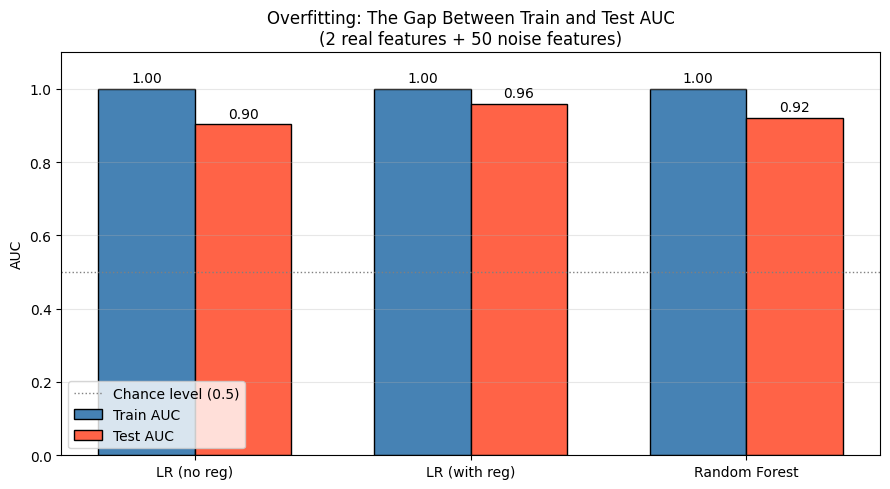

The gap between blue (train) and red (test) bars is overfitting.
The model learned patterns in the noise that do not generalize to new data.


In [7]:
# --- Bar chart: train AUC vs test AUC for each model ---
models = ['LR (no reg)', 'LR (with reg)', 'Random Forest']
train_aucs = [train_auc_lr_noreg, train_auc_lr_reg, train_auc_rf]
test_aucs = [test_auc_lr_noreg, test_auc_lr_reg, test_auc_rf]

x_pos = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x_pos - width/2, train_aucs, width, label='Train AUC',
                     color='steelblue', edgecolor='black')
bars_test = ax.bar(x_pos + width/2, test_aucs, width, label='Test AUC',
                    color='tomato', edgecolor='black')

# Add value labels on bars
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='Chance level (0.5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylabel('AUC')
ax.set_title('Overfitting: The Gap Between Train and Test AUC\n(2 real features + 50 noise features)')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("The gap between blue (train) and red (test) bars is overfitting.")
print("The model learned patterns in the noise that do not generalize to new data.")

**This is exactly our situation with the real data.** We have 93 features and only 134 samples. Many of those features may be noise (unrelated to rejection status). Without proper safeguards like regularization and feature selection, a model will happily memorize noise patterns in the training data and then fail completely on new data.

The gap between train AUC and test AUC is the **overfitting gap**. A large gap means the model is memorizing rather than learning.

---
## Section 7: Cross-Validation

A single train/test split has a problem: the results depend on **which specific samples** ended up in the training set and which ended up in the test set. You might get lucky or unlucky.

**Cross-validation** removes this luck factor by averaging over multiple splits.

### K-Fold Cross-Validation (step by step)

With K=5:

1. Shuffle and split the data into 5 equal parts ("folds")
2. **Round 1**: Train on folds 1, 2, 3, 4. Test on fold 5. Record the score.
3. **Round 2**: Train on folds 1, 2, 3, 5. Test on fold 4. Record the score.
4. **Round 3**: Train on folds 1, 2, 4, 5. Test on fold 3. Record the score.
5. **Round 4**: Train on folds 1, 3, 4, 5. Test on fold 2. Record the score.
6. **Round 5**: Train on folds 2, 3, 4, 5. Test on fold 1. Record the score.
7. **Final result**: average the 5 scores. Also report the standard deviation to see how much the score varies across folds.

Every sample gets to be in the test set exactly once. This gives a much more reliable estimate of performance.

### Stratified cross-validation

"Stratified" means that each fold preserves the original class ratio. In our data, 29% of samples are rejection cases. Stratified CV ensures that each fold also has roughly 29% rejection cases. This prevents the unlucky situation where one fold has very few (or very many) rejection cases.

In [8]:
# --- Manual 5-fold stratified cross-validation on the toy data ---
np.random.seed(42)

# Set up the cross-validation splitter
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store the AUC for each fold
fold_aucs = []

print("=== Manual 5-Fold Stratified Cross-Validation ===")
print()

for fold_number, (train_index, test_index) in enumerate(skf.split(X_toy, y_toy), 1):
    # Split the data for this fold
    X_train_fold = X_toy[train_index]
    y_train_fold = y_toy[train_index]
    X_test_fold = X_toy[test_index]
    y_test_fold = y_toy[test_index]

    # Train a logistic regression model
    model = LogisticRegression(random_state=42)
    model.fit(X_train_fold, y_train_fold)

    # Get predicted probabilities for the test fold
    y_prob_fold = model.predict_proba(X_test_fold)[:, 1]

    # Compute AUC for this fold
    fold_auc = roc_auc_score(y_test_fold, y_prob_fold)
    fold_aucs.append(fold_auc)

    print(f"Fold {fold_number}: "
          f"Train size = {len(train_index)}, "
          f"Test size = {len(test_index)}, "
          f"Test class 1 ratio = {y_test_fold.mean():.2f}, "
          f"AUC = {fold_auc:.3f}")

print()
print(f"Mean AUC across 5 folds: {np.mean(fold_aucs):.3f}")
print(f"Std  AUC across 5 folds: {np.std(fold_aucs):.3f}")
print()

# Verify with sklearn's built-in cross_val_score
cv_scores = cross_val_score(
    LogisticRegression(random_state=42), X_toy, y_toy,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)

print("=== Verification with sklearn's cross_val_score ===")
print(f"Scores per fold: {[f'{s:.3f}' for s in cv_scores]}")
print(f"Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print()
print("The results match, confirming our manual implementation is correct.")

=== Manual 5-Fold Stratified Cross-Validation ===

Fold 1: Train size = 96, Test size = 24, Test class 1 ratio = 0.33, AUC = 0.969
Fold 2: Train size = 96, Test size = 24, Test class 1 ratio = 0.33, AUC = 0.945
Fold 3: Train size = 96, Test size = 24, Test class 1 ratio = 0.33, AUC = 0.977
Fold 4: Train size = 96, Test size = 24, Test class 1 ratio = 0.33, AUC = 0.945
Fold 5: Train size = 96, Test size = 24, Test class 1 ratio = 0.33, AUC = 0.969

Mean AUC across 5 folds: 0.961
Std  AUC across 5 folds: 0.013

=== Verification with sklearn's cross_val_score ===
Scores per fold: ['0.969', '0.945', '0.977', '0.945', '0.969']
Mean AUC: 0.961 (+/- 0.013)

The results match, confirming our manual implementation is correct.


---
## Section 8: Key Metrics for Imbalanced Classes

Our real data has **95 no-rejection cases (71%)** and **39 rejection cases (29%)**. This imbalance has important consequences for how we evaluate a classifier.

Let's start with a revealing example.

In [9]:
# --- The "dumb classifier" that always predicts the majority class ---

# Simulate our real class distribution
y_real = np.array([0] * 95 + [1] * 39)  # 95 no-rejection, 39 rejection

# The dumb classifier: always predict "no rejection" (class 0)
y_pred_dumb = np.zeros(len(y_real), dtype=int)

# Compute metrics
acc_dumb = accuracy_score(y_real, y_pred_dumb)
cm_dumb = confusion_matrix(y_real, y_pred_dumb)

# Sensitivity: of all actual rejection cases, how many did we catch?
# TP / (TP + FN)
tp = cm_dumb[1, 1]  # true positives (predicted 1, actually 1)
fn = cm_dumb[1, 0]  # false negatives (predicted 0, actually 1)
tn = cm_dumb[0, 0]  # true negatives (predicted 0, actually 0)
fp = cm_dumb[0, 1]  # false positives (predicted 1, actually 0)

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("=== The Dumb Classifier: Always Predict 'No Rejection' ===")
print()
print(f"Accuracy:    {acc_dumb:.1%}   <-- Looks pretty good!")
print(f"Sensitivity: {sensitivity:.1%}   <-- Catches ZERO rejection cases!")
print(f"Specificity: {specificity:.1%}")
print()
print("Confusion Matrix:")
print(f"                  Predicted 0   Predicted 1")
print(f"  Actual 0 (NR):     {tn:3d}          {fp:3d}")
print(f"  Actual 1 (R):      {fn:3d}          {tp:3d}")
print()
print("71% accuracy sounds decent, but the model is completely useless --")
print("it never detects a single rejection case. This is why accuracy")
print("is a misleading metric for imbalanced data.")

=== The Dumb Classifier: Always Predict 'No Rejection' ===

Accuracy:    70.9%   <-- Looks pretty good!
Sensitivity: 0.0%   <-- Catches ZERO rejection cases!
Specificity: 100.0%

Confusion Matrix:
                  Predicted 0   Predicted 1
  Actual 0 (NR):      95            0
  Actual 1 (R):       39            0

71% accuracy sounds decent, but the model is completely useless --
it never detects a single rejection case. This is why accuracy
is a misleading metric for imbalanced data.


### Understanding Each Metric

**Accuracy** = (number of correct predictions) / (total predictions)
- Simple and intuitive, but **misleading when classes are imbalanced**. A model that always predicts the majority class achieves high accuracy while being completely useless.

**Sensitivity** (also called Recall for the positive class)
- Of all actual **rejection** cases, how many did we correctly identify?
- Formula: TP / (TP + FN)
- A sensitivity of 80% means we catch 80% of rejection cases and miss 20%.
- In medical contexts, high sensitivity is often critical -- we do not want to miss real cases.

**Specificity** (also called Recall for the negative class)
- Of all actual **no-rejection** cases, how many did we correctly label as no-rejection?
- Formula: TN / (TN + FP)
- A specificity of 90% means that 10% of healthy cases get falsely flagged as rejection.

**Precision** (also called Positive Predictive Value)
- Of all cases we **predicted** as rejection, how many truly were?
- Formula: TP / (TP + FP)
- Low precision means many false alarms.

**AUC (Area Under the ROC Curve)**
- The probability that a randomly chosen positive (rejection) case gets a higher predicted score than a randomly chosen negative (no-rejection) case.
- AUC = 0.5 means random guessing (the model cannot tell the classes apart at all)
- AUC = 1.0 means perfect separation
- AUC is **threshold-independent** -- it evaluates the model's overall ability to rank positive cases higher than negative cases, regardless of where you set the cutoff.

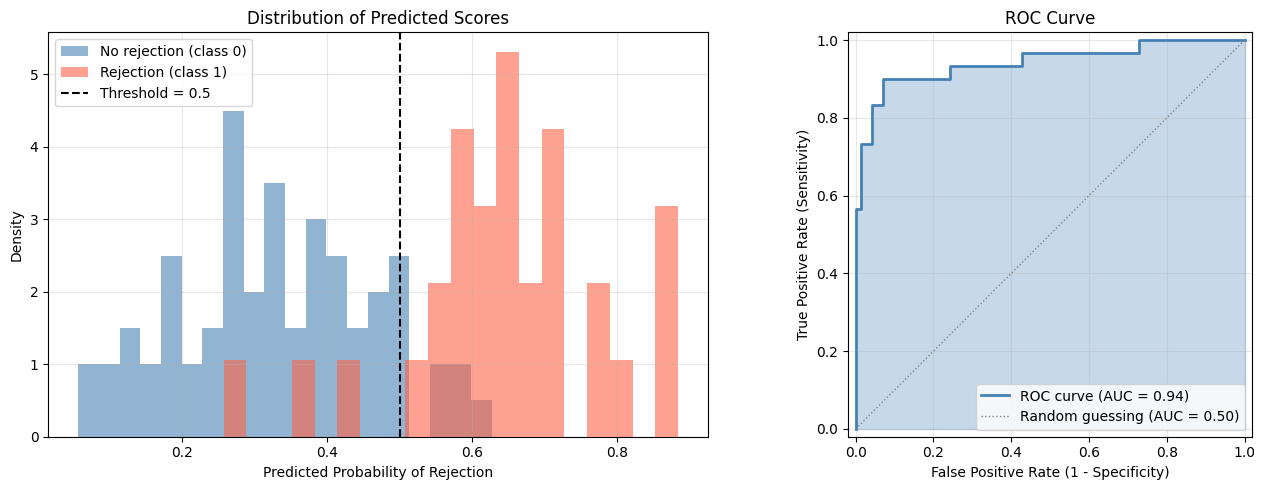

AUC = 0.94

The left plot shows the distribution of predicted scores for each class.
A good model pushes the two distributions apart.

The right plot is the ROC curve. Each point on the curve corresponds to a
different threshold. Moving the threshold changes the trade-off between
sensitivity (catching rejections) and false positive rate (false alarms).
The shaded area = AUC. Larger area = better model.


In [10]:
# --- Build an ROC curve step by step ---
np.random.seed(42)

# Create a synthetic scenario: 100 patients, 30 with rejection
n_total = 100
n_pos = 30
n_neg = 70
y_true_roc = np.array([0] * n_neg + [1] * n_pos)

# Simulate predicted probabilities from a moderately good model
# Negative cases: scores drawn from Normal(0.35, 0.15)
# Positive cases: scores drawn from Normal(0.65, 0.15)
scores_neg = np.clip(np.random.normal(0.35, 0.15, n_neg), 0, 1)
scores_pos = np.clip(np.random.normal(0.65, 0.15, n_pos), 0, 1)
y_scores_roc = np.concatenate([scores_neg, scores_pos])

# Compute ROC curve: vary threshold from 0 to 1
fpr, tpr, thresholds = roc_curve(y_true_roc, y_scores_roc)
auc_value = roc_auc_score(y_true_roc, y_scores_roc)

# Plot the ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of scores
ax1 = axes[0]
ax1.hist(scores_neg, bins=20, alpha=0.6, color='steelblue', label='No rejection (class 0)', density=True)
ax1.hist(scores_pos, bins=20, alpha=0.6, color='tomato', label='Rejection (class 1)', density=True)
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax1.set_xlabel('Predicted Probability of Rejection')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of Predicted Scores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: ROC curve
ax2 = axes[1]
ax2.fill_between(fpr, tpr, alpha=0.3, color='steelblue')
ax2.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC curve (AUC = {auc_value:.2f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1,
         label='Random guessing (AUC = 0.50)')
ax2.set_xlabel('False Positive Rate (1 - Specificity)')
ax2.set_ylabel('True Positive Rate (Sensitivity)')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.02)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"AUC = {auc_value:.2f}")
print()
print("The left plot shows the distribution of predicted scores for each class.")
print("A good model pushes the two distributions apart.")
print()
print("The right plot is the ROC curve. Each point on the curve corresponds to a")
print("different threshold. Moving the threshold changes the trade-off between")
print("sensitivity (catching rejections) and false positive rate (false alarms).")
print("The shaded area = AUC. Larger area = better model.")

The ROC curve plots sensitivity (true positive rate) against the false positive rate (1 - specificity) at every possible threshold. **AUC is threshold-independent** -- it tells you about the model's overall ability to separate the two classes, regardless of where you place the decision cutoff.

- A perfect model has AUC = 1.0 (the curve hugs the top-left corner)
- A random model has AUC = 0.5 (the curve follows the diagonal)
- AUC below 0.5 means the model is systematically wrong (flipping predictions would help)

---
## Section 9: Class Weighting

When one class is rarer than the other, the model tends to **ignore the minority class**. Why? Because predicting the majority class for every sample already gives high accuracy, and the model optimizes for accuracy by default.

**Class weighting** tells the model to pay more attention to the minority class. Misclassifying a rare sample costs more than misclassifying a common one. With `class_weight="balanced"`, sklearn automatically increases the weight of the minority class in proportion to its rarity.

In [11]:
# --- Demonstrate the effect of class weighting ---
np.random.seed(42)

# Use the toy data (80 vs 40 = imbalanced)
X_train_cw, X_test_cw, y_train_cw, y_test_cw = train_test_split(
    X_toy, y_toy, test_size=0.3, random_state=42, stratify=y_toy
)

# Model 1: No class weighting
lr_no_weight = LogisticRegression(random_state=42)
lr_no_weight.fit(X_train_cw, y_train_cw)
y_pred_no_weight = lr_no_weight.predict(X_test_cw)

sens_no_weight = recall_score(y_test_cw, y_pred_no_weight, pos_label=1)
spec_no_weight = recall_score(y_test_cw, y_pred_no_weight, pos_label=0)
auc_no_weight = roc_auc_score(y_test_cw, lr_no_weight.predict_proba(X_test_cw)[:, 1])

# Model 2: With class_weight="balanced"
lr_weighted = LogisticRegression(class_weight='balanced', random_state=42)
lr_weighted.fit(X_train_cw, y_train_cw)
y_pred_weighted = lr_weighted.predict(X_test_cw)

sens_weighted = recall_score(y_test_cw, y_pred_weighted, pos_label=1)
spec_weighted = recall_score(y_test_cw, y_pred_weighted, pos_label=0)
auc_weighted = roc_auc_score(y_test_cw, lr_weighted.predict_proba(X_test_cw)[:, 1])

print("=== Without Class Weighting ===")
print(f"  Sensitivity (minority class): {sens_no_weight:.3f}")
print(f"  Specificity (majority class): {spec_no_weight:.3f}")
print(f"  AUC:                          {auc_no_weight:.3f}")
print()
print("=== With class_weight='balanced' ===")
print(f"  Sensitivity (minority class): {sens_weighted:.3f}")
print(f"  Specificity (majority class): {spec_weighted:.3f}")
print(f"  AUC:                          {auc_weighted:.3f}")
print()
print("Class weighting typically improves sensitivity (catching more minority")
print("class cases) at the cost of slightly lower specificity (more false alarms).")
print("The AUC may stay similar because it is threshold-independent.")
print()
print("Note: the exact numbers depend on the random split. The important thing")
print("is the principle: class weighting shifts attention toward the rarer class.")

=== Without Class Weighting ===
  Sensitivity (minority class): 0.833
  Specificity (majority class): 0.917
  AUC:                          0.962

=== With class_weight='balanced' ===
  Sensitivity (minority class): 0.917
  Specificity (majority class): 0.875
  AUC:                          0.962

Class weighting typically improves sensitivity (catching more minority
class cases) at the cost of slightly lower specificity (more false alarms).
The AUC may stay similar because it is threshold-independent.

Note: the exact numbers depend on the random split. The important thing
is the principle: class weighting shifts attention toward the rarer class.


---
## Section 10: Feature Selection and the Curse of Dimensionality

### The problem with too many features

With 93 features and only 134 samples, we have a **high-dimensional problem**. This is sometimes called the **curse of dimensionality**.

A common rule of thumb in statistics and machine learning: you need **10 to 20 samples per feature** for reliable learning. In our case:

- 134 samples / 93 features = **1.4 samples per feature**

This is far below the recommended ratio. With so few samples per feature, the model cannot reliably distinguish real patterns from noise. It is like trying to solve an equation with 93 unknowns but only 134 data points -- mathematically possible, but the solution will be fragile and overfit to noise.

### The redundancy problem

On top of having too many features, many of them are **highly correlated** with each other. In our radiomics data, we found 305 pairs of features with absolute correlation above 0.9. Correlated features provide the same information and make the model unstable -- small changes in the data can flip which correlated feature the model relies on.

### Feature selection approaches

**Feature selection** reduces the number of features to a manageable, less redundant set:

1. **Correlation filter**: For each pair of highly correlated features (|r| > 0.9), drop one. This removes redundancy without looking at the target variable.

2. **Univariate filter**: Keep only features that showed at least some signal in statistical tests (e.g., p-value below a lenient threshold). This removes features that clearly have no relationship with the outcome.

Let's demonstrate this on synthetic data.

In [12]:
# --- Demonstrate the benefit of feature selection ---
np.random.seed(42)

# Generate data: 120 samples
n_samples = 120
n_real = 3      # features that truly differ between groups
n_noise = 47    # features that are pure noise

# Create labels: 80 class 0, 40 class 1
y_fs = np.array([0] * 80 + [1] * 40)

# Real features: differ between groups by about 0.8 standard deviations
X_real = np.random.randn(n_samples, n_real)
for j in range(n_real):
    X_real[y_fs == 1, j] += 0.8  # shift class 1 upward

# Noise features: no relationship with the outcome
X_noise = np.random.randn(n_samples, n_noise)

# Combine
X_all = np.hstack([X_real, X_noise])     # 50 features total
X_real_only = X_real                       # just the 3 real features

print(f"Full dataset: {X_all.shape[0]} samples, {X_all.shape[1]} features")
print(f"  ({n_real} real + {n_noise} noise)")
print(f"Real-only dataset: {X_real_only.shape[0]} samples, {X_real_only.shape[1]} features")
print()

# Evaluate both using 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# With ALL 50 features
scores_all = cross_val_score(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    X_all, y_fs, cv=cv, scoring='roc_auc'
)

# With only the 3 REAL features
scores_real = cross_val_score(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    X_real_only, y_fs, cv=cv, scoring='roc_auc'
)

print("=== Logistic Regression: 5-Fold CV AUC ===")
print(f"All 50 features:     {scores_all.mean():.3f} (+/- {scores_all.std():.3f})")
print(f"Only 3 real features: {scores_real.mean():.3f} (+/- {scores_real.std():.3f})")
print()
print("Removing the noise features improves or maintains performance.")
print("More features is NOT always better -- especially when many are noise.")

Full dataset: 120 samples, 50 features
  (3 real + 47 noise)
Real-only dataset: 120 samples, 3 features

=== Logistic Regression: 5-Fold CV AUC ===
All 50 features:     0.772 (+/- 0.080)
Only 3 real features: 0.866 (+/- 0.073)

Removing the noise features improves or maintains performance.
More features is NOT always better -- especially when many are noise.


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_mo

---
## Section 11: Putting It All Together -- Our Actual Data

Now let's apply everything we have learned to the real pancreas ultrasound radiomics data. We will:

1. Load the data (93 radiomics features, 134 samples)
2. Remove highly correlated features (|r| > 0.9)
3. Train logistic regression and random forest with class weighting
4. Evaluate using 5-fold stratified cross-validation
5. Report AUC, sensitivity, and specificity

In [13]:
# --- Load and prepare the real radiomics data ---

# Load the merged dataset
df = pd.read_csv('reports/13_merged_radiomics_clinical.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total studies: {len(df)}")
print()

# Get radiomics feature columns (all columns starting with "original_")
feature_cols = [col for col in df.columns if col.startswith('original_')]
print(f"Radiomics features: {len(feature_cols)}")

# Target variable
y = df['rejection'].values
print(f"Class distribution:")
print(f"  No rejection (0): {np.sum(y == 0)}")
print(f"  Rejection (1):    {np.sum(y == 1)}")
print(f"  Rejection rate:   {np.mean(y):.1%}")
print()

# Feature matrix
X = df[feature_cols].values
print(f"Feature matrix shape: {X.shape}")
print(f"Samples per feature ratio: {X.shape[0] / X.shape[1]:.1f}")

# Check for any missing values
n_missing = np.sum(np.isnan(X))
print(f"Missing values: {n_missing}")

Dataset shape: (134, 100)
Total studies: 134

Radiomics features: 93
Class distribution:
  No rejection (0): 95
  Rejection (1):    39
  Rejection rate:   29.1%

Feature matrix shape: (134, 93)
Samples per feature ratio: 1.4
Missing values: 0


In [14]:
# --- Remove highly correlated features ---

# Compute the correlation matrix
corr_matrix = np.abs(np.corrcoef(X, rowvar=False))

# Find features to drop: for each pair with |r| > 0.9, drop the second one
n_features = X.shape[1]
features_to_drop = set()

for i in range(n_features):
    if i in features_to_drop:
        continue
    for j in range(i + 1, n_features):
        if j in features_to_drop:
            continue
        if corr_matrix[i, j] > 0.9:
            features_to_drop.add(j)

# Create reduced feature set
features_to_keep = [i for i in range(n_features) if i not in features_to_drop]
X_reduced = X[:, features_to_keep]
kept_feature_names = [feature_cols[i] for i in features_to_keep]

print(f"Original features:  {n_features}")
print(f"Dropped (|r|>0.9):  {len(features_to_drop)}")
print(f"Remaining features: {len(features_to_keep)}")
print(f"New samples-per-feature ratio: {X_reduced.shape[0] / X_reduced.shape[1]:.1f}")
print()
print("Remaining features:")
for i, name in enumerate(kept_feature_names):
    print(f"  {i+1:2d}. {name}")

Original features:  93
Dropped (|r|>0.9):  62
Remaining features: 31
New samples-per-feature ratio: 4.3

Remaining features:
   1. original_firstorder_10Percentile
   2. original_firstorder_Energy
   3. original_firstorder_Entropy
   4. original_firstorder_Kurtosis
   5. original_firstorder_Maximum
   6. original_firstorder_Range
   7. original_firstorder_Skewness
   8. original_glcm_Autocorrelation
   9. original_glcm_ClusterProminence
  10. original_glcm_ClusterShade
  11. original_glcm_Contrast
  12. original_glcm_Correlation
  13. original_glcm_Idmn
  14. original_glcm_Idn
  15. original_glcm_MaximumProbability
  16. original_glrlm_GrayLevelNonUniformity
  17. original_glrlm_LongRunEmphasis
  18. original_glrlm_LongRunHighGrayLevelEmphasis
  19. original_glrlm_LongRunLowGrayLevelEmphasis
  20. original_glrlm_LowGrayLevelRunEmphasis
  21. original_glrlm_RunEntropy
  22. original_glrlm_RunLengthNonUniformity
  23. original_glrlm_ShortRunEmphasis
  24. original_glrlm_ShortRunHighGrayL

In [15]:
# --- 5-Fold Stratified CV with Logistic Regression and Random Forest ---
np.random.seed(42)

# Standardize features (important for logistic regression)
scaler = StandardScaler()

# Set up cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each model
results = {
    'Logistic Regression': {'auc': [], 'sensitivity': [], 'specificity': []},
    'Random Forest':       {'auc': [], 'sensitivity': [], 'specificity': []},
}

for fold_num, (train_idx, test_idx) in enumerate(cv.split(X_reduced, y), 1):
    X_train_fold = X_reduced[train_idx]
    X_test_fold = X_reduced[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]

    # Standardize (fit on train, transform both)
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)

    # --- Logistic Regression ---
    lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train_fold)
    y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
    y_pred_lr = lr.predict(X_test_scaled)

    results['Logistic Regression']['auc'].append(roc_auc_score(y_test_fold, y_prob_lr))
    results['Logistic Regression']['sensitivity'].append(recall_score(y_test_fold, y_pred_lr, pos_label=1))
    results['Logistic Regression']['specificity'].append(recall_score(y_test_fold, y_pred_lr, pos_label=0))

    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X_train_scaled, y_train_fold)
    y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
    y_pred_rf = rf.predict(X_test_scaled)

    results['Random Forest']['auc'].append(roc_auc_score(y_test_fold, y_prob_rf))
    results['Random Forest']['sensitivity'].append(recall_score(y_test_fold, y_pred_rf, pos_label=1))
    results['Random Forest']['specificity'].append(recall_score(y_test_fold, y_pred_rf, pos_label=0))

# Print results
print("=" * 65)
print("5-Fold Stratified Cross-Validation Results (Real Radiomics Data)")
print("=" * 65)
print()

for model_name, metrics in results.items():
    print(f"--- {model_name} ---")
    for metric_name in ['auc', 'sensitivity', 'specificity']:
        values = metrics[metric_name]
        mean_val = np.mean(values)
        std_val = np.std(values)
        per_fold = ', '.join([f'{v:.2f}' for v in values])
        print(f"  {metric_name.capitalize():13s}: {mean_val:.3f} (+/- {std_val:.3f})  [{per_fold}]")
    print()

/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_mo

5-Fold Stratified Cross-Validation Results (Real Radiomics Data)

--- Logistic Regression ---
  Auc          : 0.438 (+/- 0.087)  [0.37, 0.57, 0.32, 0.47, 0.45]
  Sensitivity  : 0.436 (+/- 0.056)  [0.38, 0.50, 0.38, 0.50, 0.43]
  Specificity  : 0.421 (+/- 0.133)  [0.26, 0.58, 0.26, 0.47, 0.53]

--- Random Forest ---
  Auc          : 0.528 (+/- 0.094)  [0.46, 0.59, 0.45, 0.46, 0.68]
  Sensitivity  : 0.100 (+/- 0.146)  [0.00, 0.38, 0.12, 0.00, 0.00]
  Specificity  : 0.947 (+/- 0.058)  [1.00, 0.95, 0.84, 1.00, 0.95]



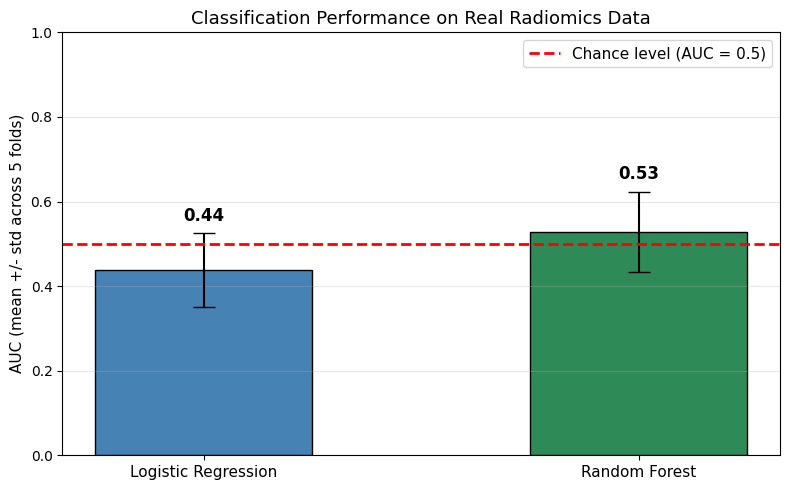

Both models perform near the chance level (AUC = 0.5).
The radiomics features cannot distinguish rejection from no-rejection.


In [16]:
# --- Visualize the results compared to chance ---

model_names = list(results.keys())
mean_aucs = [np.mean(results[m]['auc']) for m in model_names]
std_aucs = [np.std(results[m]['auc']) for m in model_names]

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(model_names))
bars = ax.bar(x_pos, mean_aucs, yerr=std_aucs, capsize=8,
              color=['steelblue', 'seagreen'], edgecolor='black', width=0.5)

# Add value labels
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std_aucs[i] + 0.02,
            f'{mean_aucs[i]:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Chance level (AUC = 0.5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('AUC (mean +/- std across 5 folds)', fontsize=11)
ax.set_title('Classification Performance on Real Radiomics Data', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Both models perform near the chance level (AUC = 0.5).")
print("The radiomics features cannot distinguish rejection from no-rejection.")

### Interpreting the results

AUC around 0.5 means the model **cannot distinguish rejection from no-rejection** using these radiomics features. It is performing at chance level -- no better than flipping a coin.

This is consistent with the statistical analysis from notebook 14a, where no individual feature showed a significant difference between the groups.

### What this does NOT mean

This result does **not** mean that machine learning is useless in general, or that radiomics is a dead end for all problems. It means that **these particular features**, extracted from **these particular images**, with **this sample size**, do not carry enough discriminative signal for this specific classification task.

There are many possible reasons:
- The radiomics features we extracted may not capture the relevant tissue changes that occur during rejection
- Ultrasound image quality and variability may obscure subtle differences
- The sample size (134 studies, only 39 rejections) may be too small to detect a weak signal
- Rejection may not produce consistent, quantifiable changes visible in the radiomics features we used

The important thing is that we applied proper methodology (cross-validation, class weighting, feature reduction) and can be confident in the negative result.

---
## Section 12: Summary

### Key Takeaways

1. **ML classifiers combine features to predict group membership.** Unlike statistical tests that examine features one by one, a classifier looks at all features simultaneously and learns a decision rule. This can potentially combine many weak signals into a stronger prediction -- but only if those signals actually exist.

2. **Train/test splits prevent measuring memorization instead of understanding.** If you evaluate a model on the same data it was trained on, you are testing its ability to memorize, not to generalize. Always hold out data the model has never seen for evaluation.

3. **Cross-validation averages over multiple splits for a robust estimate.** A single train/test split is subject to luck. K-fold cross-validation trains and tests K times, using each portion of the data as the test set exactly once. The average score is a more reliable measure of true performance.

4. **AUC is the preferred metric for imbalanced data, not accuracy.** With 71% of our data in the majority class, a model that always predicts "no rejection" achieves 71% accuracy while being completely useless. AUC measures the model's ability to rank positive cases higher than negative cases, regardless of the class balance.

5. **Overfitting happens when models learn noise.** With 93 features and only 134 samples (1.4 samples per feature), the risk of overfitting is very high. Regularization, feature selection, and proper evaluation (cross-validation) are essential safeguards.

6. **Our results (AUC around 0.5) confirm the statistical finding.** Both logistic regression and random forest performed at chance level. The radiomics features extracted from pancreas ultrasound images do not discriminate rejection from no-rejection in this dataset. This is a valid and meaningful negative result.